In [1]:
!pip -q install kagglehub scikit-image

In [2]:
import os, re, random, time
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
import kagglehub
from joblib import Parallel, delayed
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

IMG_SIZE = 128                    # common resolution
NORMAL_CLASSES = ["crazing"]      # <-- classes treated as "Non-Defective" in binary mode (assumption!)

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Path to dataset files: /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split
Total images: 1800
split            unknown
class                   
crazing              300
inclusion            300
patches              300
pitted_surface       300
rolled-in_scale      300
scratches            300
Created own 80/20 split.
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


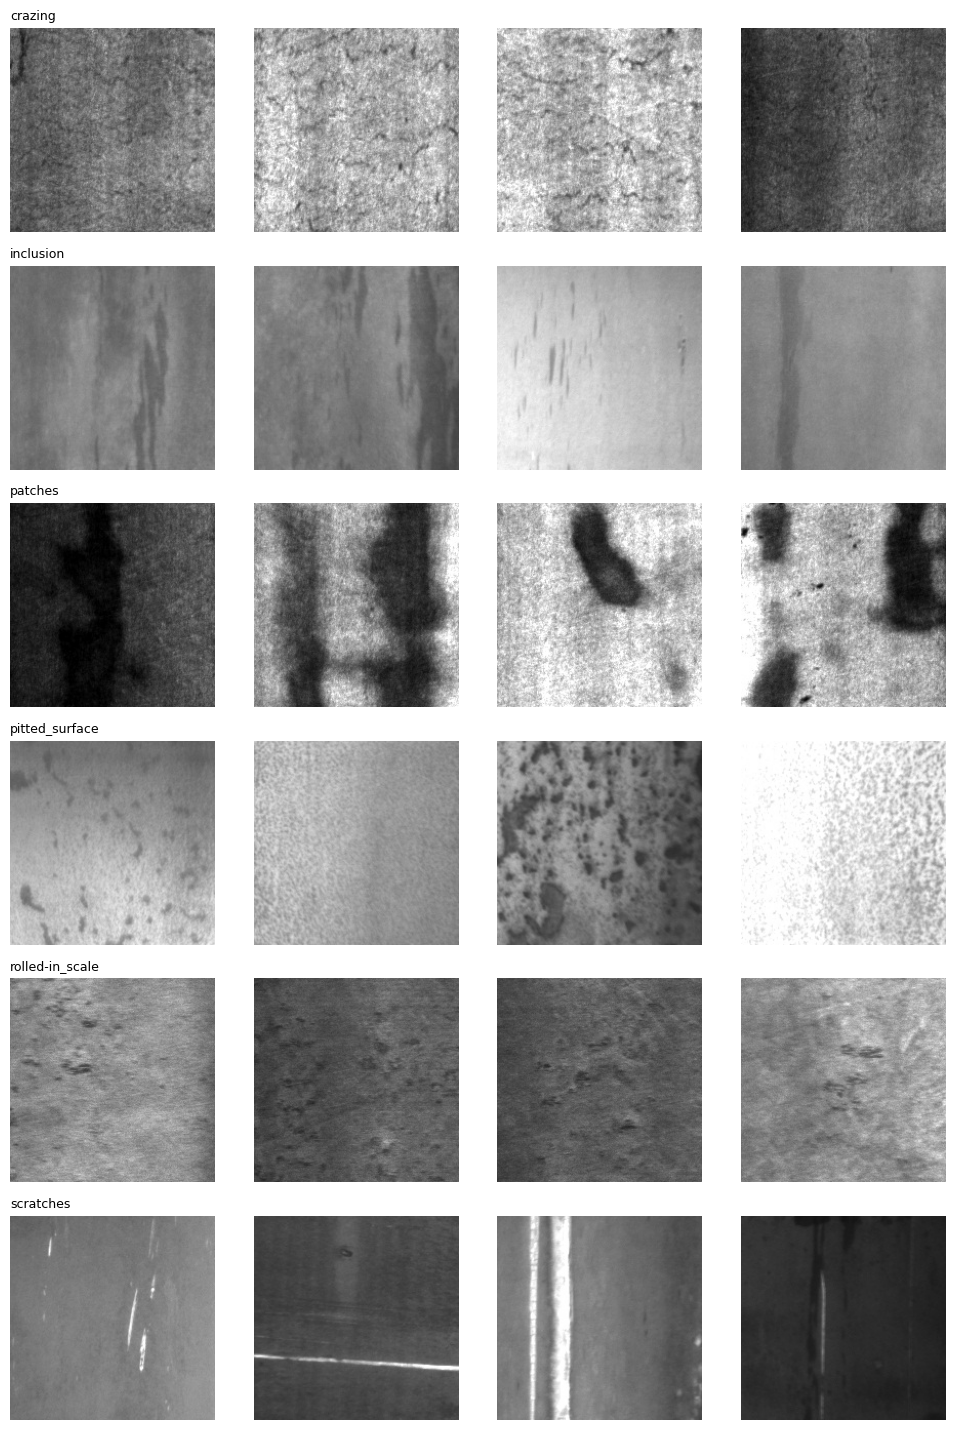

In [3]:
path = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")
print("Path to dataset files:", path)

exts = (".jpg", ".jpeg", ".png", ".bmp")
rows = []
for root, _, files in os.walk(path):
    rel = os.path.relpath(root, path).lower().split(os.sep)
    if any(p in ("train", "training") for p in rel):
        split = "train"
    elif any(p in ("valid", "val", "validation") for p in rel):
        split = "valid"
    else:
        split = "unknown"
    for f in files:
        if f.lower().endswith(exts):
            m = re.match(r"^(.*?)_\d+\.", f)      # e.g. rolled-in_scale_12.jpg -> rolled-in_scale
            if m:
                rows.append({"file": os.path.join(root, f), "class": m.group(1), "split": split})

df = pd.DataFrame(rows)
print("Total images:", len(df))
print(df.groupby(["split", "class"]).size().unstack(0).fillna(0).astype(int))

# if the train/valid folders were not detected, make our own stratified split
if (df["split"] == "unknown").any() or df["split"].nunique() < 2:
    tr_idx, va_idx = train_test_split(df.index, test_size=0.2, stratify=df["class"], random_state=SEED)
    df["split"] = "train"; df.loc[va_idx, "split"] = "valid"
    print("Created own 80/20 split.")

class_names = sorted(df["class"].unique())
print("Classes:", class_names)

# show a few samples per class
fig, axes = plt.subplots(len(class_names), 4, figsize=(10, 2.4 * len(class_names)))
for i, c in enumerate(class_names):
    sample = df[df["class"] == c].sample(4, random_state=SEED)["file"].tolist()
    for j, fp in enumerate(sample):
        axes[i, j].imshow(cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB))
        axes[i, j].axis("off")
        if j == 0: axes[i, j].set_title(c, fontsize=9, loc="left")
plt.tight_layout(); plt.show()

In [4]:
def preprocess(fp):
    img = cv2.imread(fp)                                  # BGR
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)          # grayscale
    return cv2.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # common size

train_df = df[df.split == "train"].reset_index(drop=True)
test_df  = df[df.split == "valid"].reset_index(drop=True)

X_train_img = np.array([preprocess(f) for f in train_df.file])
X_test_img  = np.array([preprocess(f) for f in test_df.file])

# labels: multi-class and binary (0 = non-defective, 1 = defective)
y_train_multi = np.array([class_names.index(c) for c in train_df["class"]])
y_test_multi  = np.array([class_names.index(c) for c in test_df["class"]])
y_train = np.array([0 if c in NORMAL_CLASSES else 1 for c in train_df["class"]])
y_test  = np.array([0 if c in NORMAL_CLASSES else 1 for c in test_df["class"]])

print("Train:", X_train_img.shape, " Test:", X_test_img.shape)
print("Binary train counts (0=normal,1=defective):", np.bincount(y_train))

Train: (1440, 128, 128)  Test: (360, 128, 128)
Binary train counts (0=normal,1=defective): [ 240 1200]


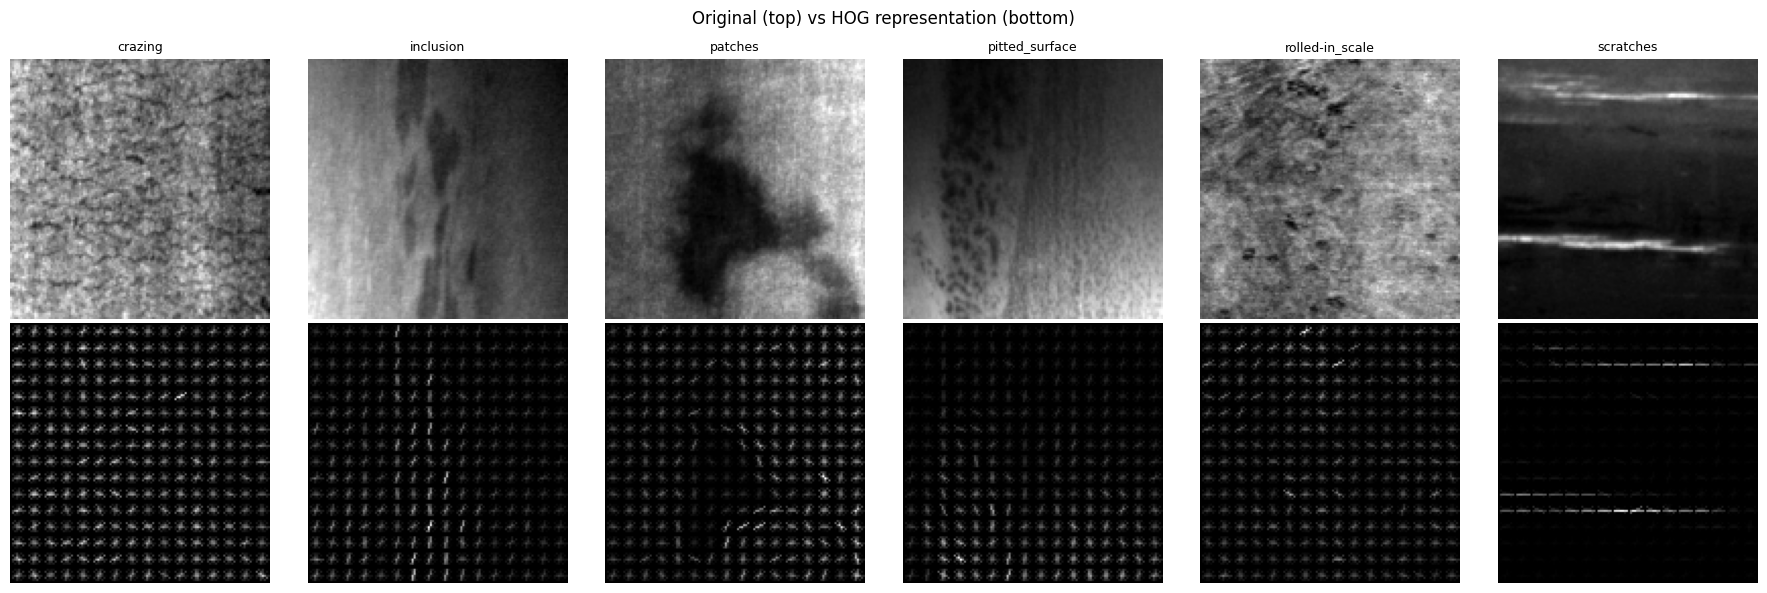

In [5]:
def hog_one(img, cell=8, orient=9):
    return hog(img, orientations=orient, pixels_per_cell=(cell, cell),
               cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True)

def extract_hog(imgs, cell=8, orient=9):
    feats = Parallel(n_jobs=-1)(delayed(hog_one)(im, cell, orient) for im in imgs)
    return np.array(feats, dtype=np.float32)

# visualize HOG for one image per class
fig, axes = plt.subplots(2, len(class_names), figsize=(3 * len(class_names), 6))
for j, c in enumerate(class_names):
    idx = np.where(y_train_multi == j)[0][0]
    img = X_train_img[idx]
    _, hog_img = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                     visualize=True, block_norm="L2-Hys")
    axes[0, j].imshow(img, cmap="gray"); axes[0, j].set_title(c, fontsize=9); axes[0, j].axis("off")
    axes[1, j].imshow(hog_img, cmap="gray"); axes[1, j].axis("off")
axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("HOG")
plt.suptitle("Original (top) vs HOG representation (bottom)"); plt.tight_layout(); plt.show()

HOG feature length: 8100

=== HOG + SVM ===
               precision    recall  f1-score   support

Non-Defective       0.90      0.92      0.91        60
    Defective       0.98      0.98      0.98       300

     accuracy                           0.97       360
    macro avg       0.94      0.95      0.95       360
 weighted avg       0.97      0.97      0.97       360



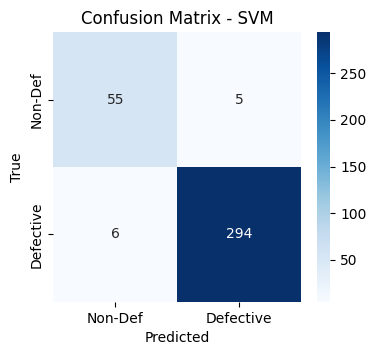


=== HOG + RandomForest ===
               precision    recall  f1-score   support

Non-Defective       0.83      0.17      0.28        60
    Defective       0.86      0.99      0.92       300

     accuracy                           0.86       360
    macro avg       0.84      0.58      0.60       360
 weighted avg       0.85      0.86      0.81       360



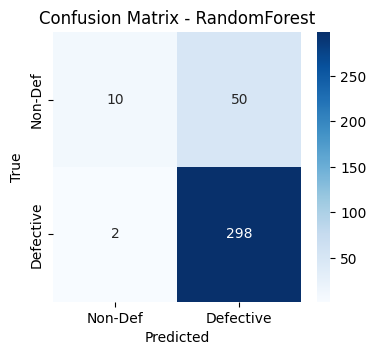


=== HOG + KNN ===
               precision    recall  f1-score   support

Non-Defective       0.80      0.82      0.81        60
    Defective       0.96      0.96      0.96       300

     accuracy                           0.94       360
    macro avg       0.88      0.89      0.89       360
 weighted avg       0.94      0.94      0.94       360



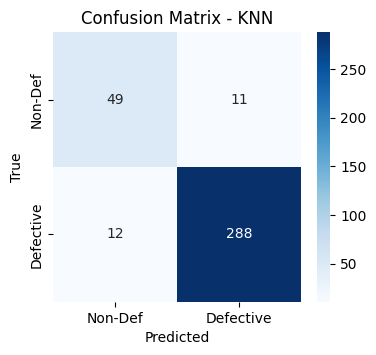

,Model,Accuracy,Precision,Recall,F1,Time(s)
0,SVM,0.9694,0.9833,0.9800,0.9816,30.0
1,RandomForest,0.8556,0.8563,0.9933,0.9198,29.4
2,KNN,0.9361,0.9632,0.9600,0.9616,0.4


In [6]:
def make_model(name, proba=True):
    if name == "SVM":
        return make_pipeline(StandardScaler(),
                             SVC(kernel="rbf", C=10, gamma="scale", probability=proba,
                                 class_weight="balanced", random_state=SEED))
    if name == "RandomForest":
        return RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                      n_jobs=-1, random_state=SEED)
    if name == "KNN":
        return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights="distance"))

def metrics(y_true, y_pred, avg="binary"):
    return dict(Accuracy=accuracy_score(y_true, y_pred),
                Precision=precision_score(y_true, y_pred, average=avg, zero_division=0),
                Recall=recall_score(y_true, y_pred, average=avg, zero_division=0),
                F1=f1_score(y_true, y_pred, average=avg, zero_division=0))

CELL, ORIENT = 8, 9   # baseline HOG settings
Xtr = extract_hog(X_train_img, CELL, ORIENT)
Xte = extract_hog(X_test_img,  CELL, ORIENT)
print("HOG feature length:", Xtr.shape[1])

results, trained = [], {}
for name in ["SVM", "RandomForest", "KNN"]:
    t0 = time.time()
    model = make_model(name).fit(Xtr, y_train)
    pred = model.predict(Xte)
    trained[name] = model
    results.append({"Model": name, **metrics(y_test, pred), "Time(s)": round(time.time() - t0, 1)})
    print(f"\n=== HOG + {name} ===")
    print(classification_report(y_test, pred, target_names=["Non-Defective", "Defective"], zero_division=0))
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Def", "Defective"], yticklabels=["Non-Def", "Defective"])
    plt.title(f"Confusion Matrix - {name}"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()

pd.DataFrame(results).round(4)

done cell=4, orient=6
done cell=4, orient=9
done cell=4, orient=12
done cell=8, orient=6
done cell=8, orient=9
done cell=8, orient=12
done cell=16, orient=6
done cell=16, orient=9
done cell=16, orient=12


,Cell,Orient,Model,Features,Accuracy,Precision,Recall,F1
0,4x4,6,SVM,23064,0.9278,0.9255,0.9933,0.9582
1,4x4,6,RandomForest,23064,0.8333,0.8333,1.0000,0.9091
2,4x4,9,SVM,34596,0.8361,0.8375,0.9967,0.9102
3,4x4,9,RandomForest,34596,0.8333,0.8333,1.0000,0.9091
4,4x4,12,SVM,46128,0.8611,0.8571,1.0000,0.9231
5,4x4,12,RandomForest,46128,0.8333,0.8333,1.0000,0.9091
6,8x8,6,SVM,5400,0.9778,1.0000,0.9733,0.9865
7,8x8,6,RandomForest,5400,0.8750,0.8761,0.9900,0.9296
8,8x8,9,SVM,8100,0.9694,0.9833,0.9800,0.9816
9,8x8,9,RandomForest,8100,0.8556,0.8563,0.9933,0.9198


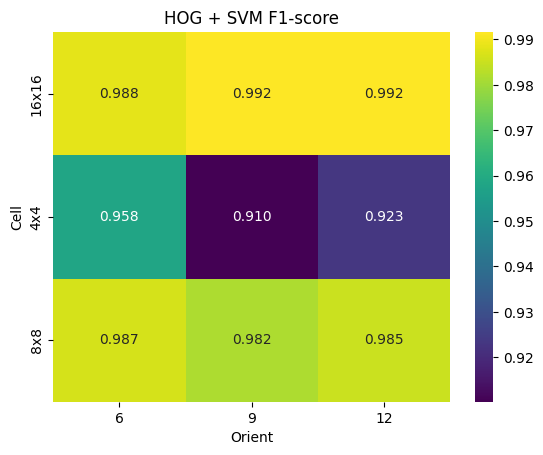

Best HOG config for SVM -> cell: 16  orientations: 9


In [7]:
grid = []
for cell in [4, 8, 16]:
    for orient in [6, 9, 12]:
        Xtr_g = extract_hog(X_train_img, cell, orient)
        Xte_g = extract_hog(X_test_img,  cell, orient)
        for name in ["SVM", "RandomForest"]:
            m = make_model(name, proba=False).fit(Xtr_g, y_train)
            r = metrics(y_test, m.predict(Xte_g))
            grid.append({"Cell": f"{cell}x{cell}", "Orient": orient, "Model": name,
                         "Features": Xtr_g.shape[1], **r})
        print(f"done cell={cell}, orient={orient}")

grid_df = pd.DataFrame(grid).round(4)
display(grid_df)

pivot = grid_df[grid_df.Model == "SVM"].pivot(index="Cell", columns="Orient", values="F1")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis"); plt.title("HOG + SVM F1-score"); plt.show()

best = grid_df[grid_df.Model == "SVM"].sort_values("F1", ascending=False).iloc[0]
BEST_CELL, BEST_ORIENT = int(best.Cell.split("x")[0]), int(best.Orient)
print("Best HOG config for SVM -> cell:", BEST_CELL, " orientations:", BEST_ORIENT)

                 precision    recall  f1-score   support

        crazing       0.90      1.00      0.94        60
      inclusion       0.92      0.97      0.94        60
        patches       0.94      0.73      0.82        60
 pitted_surface       0.84      0.93      0.88        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.98      0.92      0.95        60

       accuracy                           0.93       360
      macro avg       0.93      0.93      0.92       360
   weighted avg       0.93      0.93      0.92       360

{'Accuracy': 0.925, 'Precision': 0.9283818790209707, 'Recall': 0.9250000000000002, 'F1': 0.9234278088414395}


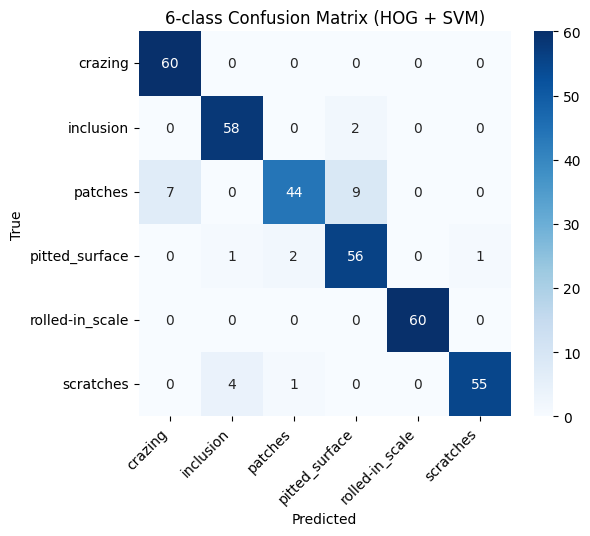

In [8]:
Xtr_b = extract_hog(X_train_img, BEST_CELL, BEST_ORIENT)
Xte_b = extract_hog(X_test_img,  BEST_CELL, BEST_ORIENT)

svm_multi = make_model("SVM").fit(Xtr_b, y_train_multi)
pred_m = svm_multi.predict(Xte_b)
print(classification_report(y_test_multi, pred_m, target_names=class_names, zero_division=0))
print(metrics(y_test_multi, pred_m, avg="macro"))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_multi, pred_m), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45, ha="right"); plt.title("6-class Confusion Matrix (HOG + SVM)")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()

,Condition,Accuracy,Precision,Recall,F1,ΔAccuracy,ΔF1
0,Original,0.9861,1.0000,0.9833,0.9916,0.0000,0.0000
1,Brightness +50,0.9722,0.9801,0.9867,0.9834,-0.0139,-0.0082
2,Brightness -50,0.9861,1.0000,0.9833,0.9916,0.0000,0.0000
3,Gaussian noise (σ=20),0.3000,1.0000,0.1600,0.2759,-0.6861,-0.7157
4,Rotation 15°,0.9194,0.9119,1.0000,0.9539,-0.0667,-0.0377
5,"Blur (7x7, σ=2)",0.8333,0.8333,1.0000,0.9091,-0.1528,-0.0825


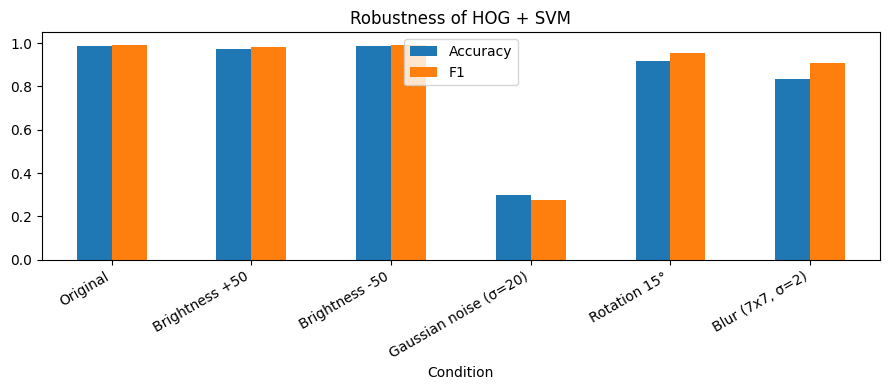

In [9]:
final_model = make_model("SVM").fit(Xtr_b, y_train)     # final binary model (best HOG config)

def brighter(im):  return cv2.convertScaleAbs(im, alpha=1.0, beta=50)
def darker(im):    return cv2.convertScaleAbs(im, alpha=1.0, beta=-50)
def noisy(im):
    return np.clip(im.astype(np.float32) + np.random.normal(0, 20, im.shape), 0, 255).astype(np.uint8)
def rotated(im, angle=15):
    M = cv2.getRotationMatrix2D((IMG_SIZE / 2, IMG_SIZE / 2), angle, 1.0)
    return cv2.warpAffine(im, M, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT)
def blurred(im):   return cv2.GaussianBlur(im, (7, 7), 2)

conditions = {"Original": lambda im: im, "Brightness +50": brighter, "Brightness -50": darker,
              "Gaussian noise (σ=20)": noisy, "Rotation 15°": rotated, "Blur (7x7, σ=2)": blurred}

rob = []
for cname, fn in conditions.items():
    imgs = np.array([fn(im) for im in X_test_img])
    pred = final_model.predict(extract_hog(imgs, BEST_CELL, BEST_ORIENT))
    rob.append({"Condition": cname, **metrics(y_test, pred)})
rob_df = pd.DataFrame(rob)
rob_df["ΔAccuracy"] = rob_df["Accuracy"] - rob_df.loc[0, "Accuracy"]
rob_df["ΔF1"] = rob_df["F1"] - rob_df.loc[0, "F1"]
display(rob_df.round(4))

rob_df.set_index("Condition")[["Accuracy", "F1"]].plot(kind="bar", figsize=(9, 4), ylim=(0, 1.05))
plt.title("Robustness of HOG + SVM"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

True class: patches
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100.0%
Likely defect type: pitted_surface
Action: REJECT PRODUCT


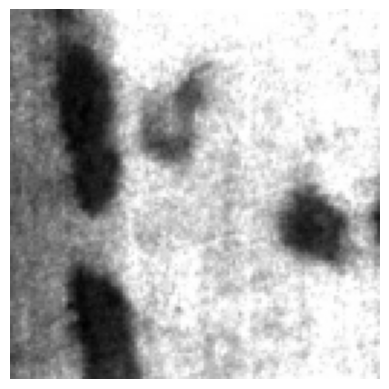

True class: inclusion
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100.0%
Likely defect type: inclusion
Action: REJECT PRODUCT


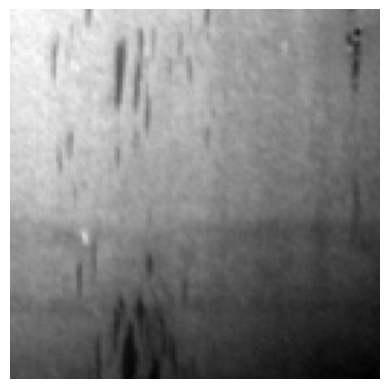

True class: pitted_surface
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 97.9%
Likely defect type: pitted_surface
Action: REJECT PRODUCT


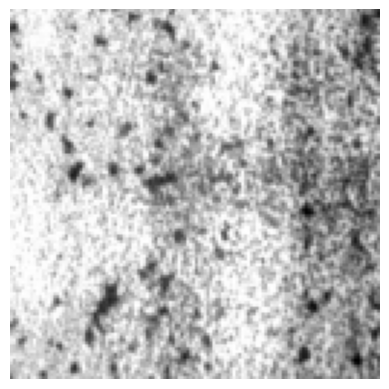

True class: scratches
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100.0%
Likely defect type: scratches
Action: REJECT PRODUCT


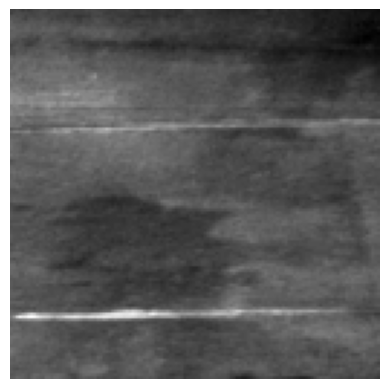

In [10]:
def inspect_product(img_path, model=final_model, show=True):
    img = preprocess(img_path)
    feat = hog_one(img, BEST_CELL, BEST_ORIENT).reshape(1, -1)
    proba = model.predict_proba(feat)[0]
    label = int(np.argmax(proba))
    conf = proba[label] * 100
    defect_type = class_names[int(svm_multi.predict(feat)[0])]

    print("=" * 36)
    print("PRODUCT INSPECTION RESULT")
    if label == 1:
        print("Prediction: DEFECTIVE")
        print(f"Confidence: {conf:.1f}%")
        print(f"Likely defect type: {defect_type}")
        print("Action: REJECT PRODUCT")
    else:
        print("Prediction: NON-DEFECTIVE")
        print(f"Confidence: {conf:.1f}%")
        print("Action: ACCEPT PRODUCT")
    print("=" * 36)
    if show:
        plt.imshow(img, cmap="gray"); plt.axis("off"); plt.show()
    return label, conf

# demo on a few random test images
for i in np.random.choice(len(test_df), 4, replace=False):
    print("True class:", test_df["class"][i])
    inspect_product(test_df.file[i])

## Bonus: video-stream prototype (PASS / DEFECTIVE)

In [13]:
def run_video(src, out_path="inspection_output.mp4", max_frames=300):
    cap = cv2.VideoCapture(src)
    w, h = int(cap.get(3)), int(cap.get(4))
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), 20, (w, h))
    n = 0
    while cap.isOpened() and n < max_frames:
        ok, frame = cap.read()
        if not ok: break
        gray = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (IMG_SIZE, IMG_SIZE))
        feat = hog_one(gray, BEST_CELL, BEST_ORIENT).reshape(1, -1)
        p = final_model.predict_proba(feat)[0]
        status, color = ("DEFECTIVE", (0, 0, 255)) if p.argmax() == 1 else ("PASS", (0, 200, 0))
        cv2.putText(frame, f"{status} ({p.max()*100:.0f}%)", (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        out.write(frame); n += 1
    cap.release(); out.release()
    print("Saved:", out_path)

# run_video("/content/your_video.mp4")   # upload a video to Colab first, then uncomment